In [1]:
import numpy as np
import torch

from matplotlib import pyplot as plt
from matplotlib.ticker import ScalarFormatter, MaxNLocator
import pandas as pd
import os
import sys

c_directory = os.getcwd()
sys.path.append(os.path.dirname(c_directory))

import architecture
import FCYeast2_simulator

device='cpu'
l10=np.log(10)
FCYeast2_simulator.adjust_device(device)

In [2]:
g3 = np.loadtxt('FCYeast2_MCMC/mcmc_real_results_116224datapoints.csv')[-100000:,:]
map_index = np.argmax(g3[:,-1])
best_param = torch.tensor(g3[map_index]).float().to(device)
best_param


tensor([ 1.3363e+01, -3.4472e-01,  2.5861e+00, -2.1814e+00, -2.2800e+00,
         1.5735e+00, -3.2391e+00, -3.2781e+05])

In [3]:
g3.shape

(100000, 8)

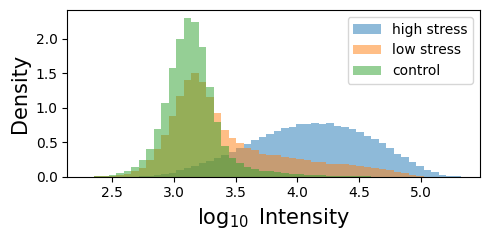

In [4]:

dils_str = ['12','23','33']
dils = [.12,.23,.33]


dfs = [pd.read_csv(os.path.dirname(c_directory) +'/clean_data/complete_d={}.csv'.format(d)) for d in dils]
x = [torch.tensor(df['FL1-A'].to_numpy().astype(np.float32)).reshape(-1,1).to(device) for df in dfs]
x = [torch.log(xi)/l10 for xi in x]

plt.figure(figsize=(5, 2.5)) 
h = np.histogram((np.concatenate([xi.numpy() for xi in x])).reshape(-1),bins=50)
lab = ['high stress','low stress','control']
[plt.hist(xi.reshape(-1).numpy(),bins=h[1],alpha=.5,density=True,label=label) for (xi,label) in zip(x,lab)]
plt.xlabel(r'$\log_{10}$ Intensity',fontsize=15)
plt.ylabel('Density',fontsize=15)
plt.legend()
plt.tight_layout()
plt.savefig('data_raw.png',dpi=500)

xlim = plt.xlim()
ylim = plt.ylim()

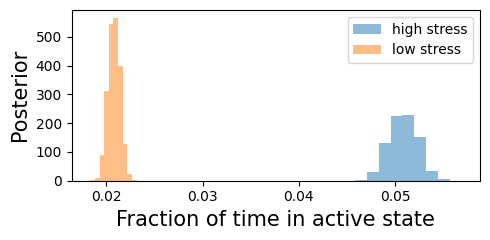

In [5]:
plt.figure(figsize=(5, 2.5)) 

lact = np.exp(g3[-100000:,1])
lina = np.exp(g3[-100000:,2])
frac = lact/(lact+lina)
plt.hist(frac,label = 'high stress',alpha=.5,density=True)

lact = np.exp(g3[-100000:,4])
lina = np.exp(g3[-100000:,5])
frac = lact/(lact+lina)
plt.hist(frac,label = 'low stress',alpha=.5,density=True)

plt.xticks(np.arange(2,6)/100)
plt.ylabel('Posterior',fontsize=15)
plt.legend()
plt.xlabel('Fraction of time in active state',fontsize=15)
plt.tight_layout()
plt.savefig('frac',dpi=600)

In [6]:
mos = [['X' ,'lact1','lina1','sig1'],
       ['bh','lact1','lina1','sig1'],
       ['bh','lact2','lina2','sig2'],
       ['X' ,'lact2','lina2','sig2']]

moA = [['bh1','lact1','lina1','sig1'],
       ['bh2','lact2','lina2','sig2']]

In [7]:
dils = [.12,.23]

def separate(x):
    return np.array(((x[0],x[1],x[2],x[3]),
                     (x[0],x[4],x[5],x[6])))

to_hours = -np.array(((0,-1,-1,0),
                     (0,-1,-1,0)))*np.log(dils).reshape(-1,1)

def transform_to_hour(x): #suppose that \betas (0 and 1) are in hours, and the other in the arbirary units. Turn them all in hours
    return separate(x) + to_hours


to_arbitrary = -np.array(((1, 0, 0, 0),
                          (1, 0, 0, 0)))*np.log(dils).reshape(-1,1)

def transform_to_arbitrary(x):  #suppose that \betas (0 and 1) are in hours, and the other in the arbirary units. Turn them all to arbitrary
    return separate(x) + to_arbitrary

def separate_sampled_par(sampled_par):
    ld1,ld2,ld3 = [],[],[]
    for sp in sampled_par:
        sp_sep = transform_to_hour(sp)
        #sp_sep=separate(sp)
        for (spi,ld) in zip(sp_sep,(ld1,ld2)):
            ld.append(1.0*spi)

    return np.stack(ld1),np.stack(ld2)

def separate_sampled_arb(sampled_par):
    ld1,ld2,ld3 = [],[],[]
    for sp in sampled_par:
        sp_sep = transform_to_arbitrary(sp)

        for (spi,ld) in zip(sp_sep,(ld1,ld2)):
            ld.append(1.0*spi)

    return np.stack(ld1),np.stack(ld2)

In [8]:
torch.exp(FCYeast2_simulator.transform_to_arbitrary((best_param)))

tensor([[5.3002e+06, 7.0842e-01, 1.3277e+01, 1.1288e-01],
        [2.7653e+06, 1.0228e-01, 4.8235e+00, 3.9198e-02]])

In [9]:
np.exp(transform_to_hour((best_param)))

array([[6.36026271e+05, 8.50101604e-02, 1.59328579e+00, 1.12880685e-01],
       [6.36026271e+05, 2.35248802e-02, 1.10941253e+00, 3.91984770e-02]])

In [10]:
tranform_fun = {'ln':lambda x:x,
                'log10': lambda x:x/np.log(10),
                'real': np.exp}
tranform_pre = {'ln': r'$\ln$',
                'log10': r'$\log_{10}$',
                'real': ''}

def make_fig(sampled_par,lp,transform = 'ln',time_scale='real'):
    if time_scale == 'real':
        fig,ax = plt.subplot_mosaic(np.array(mos).T,figsize=(6,7.5),empty_sentinel='X')
        s1,s2 = separate_sampled_par(sampled_par)
    elif time_scale == 'arbitrary':
        fig,ax = plt.subplot_mosaic(moA,figsize=(16,8))
        s1,s2 = separate_sampled_arb(sampled_par)
    
    

    gr = ['bh','lact1','lina1','sig1']
    lab = [r'$\beta$',r'$\lambda_{act}$',r'$\lambda_{ina}$',r'$\sigma$']

    fun = tranform_fun[transform]
    s1,s2 = fun(s1),fun(s2)
    prelabel = tranform_pre[transform]
    lab = [prelabel + ' ' + l + r' (${h^{-1}}$)' for l in lab[:3]] +[prelabel + ' ' + lab[3]]

    gr = ['lact1','lina1','sig1']
    [ax[gr[i]].hist(s1[:,i+1],bins=35,density=True) for i in range(3)]
    [ax[gr[i]].set_xlabel(lab[i+1] ,fontsize=15) for i in range(3)]
    ax[gr[0]].set_title(r'$\bar{{T}} ={:.2f} h$ '.format((1/dils[0]))+'\n  (high stress)',fontsize=13)

    gr = ['lact2','lina2','sig2']
    [ax[gr[i]].hist(s2[:,i+1],bins=35,density=True) for i in range(3)]
    [ax[gr[i]].set_xlabel(lab[i+1] ,fontsize=15) for i in range(3)]
    ax[gr[0]].set_title(r'$\bar{{T}} ={:.2f} h$ '.format((1/dils[1]))+'\n (low stress)',fontsize=13)

    if time_scale == 'real':
        ax['bh'].hist(s1[:,0],bins=35,density=True)
        ax['bh'].set_xlabel(lab[0],fontsize=15)

    elif time_scale == 'arbitrary':
        for (bhi,si) in zip([m[0] for m in moA],(s1,s2)):
            ax[bhi].hist(si[:,0],density=True)
            ax[bhi].set_xlabel(lab[0],fontsize=15)
       
    for axi in ax.values():
        ymax = axi.get_ylim()[1]
        pow = np.floor(np.log10(ymax))
        ticks = np.arange(0, int(np.ceil(ymax)))
            

        if len(ticks) > 4:
            ticks = np.linspace(0, ticks[-1], 3)
            ticks = (ticks/(10**pow)).astype(int)*(10**pow)

        axi.set_yticks(ticks)
        axi.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
        axi.ticklabel_format(style='sci', axis='y', scilimits=(0, 0)) 

        xticks = axi.get_xticks()
        xticks = np.linspace(xticks[0],xticks[-1],10)
        xticks = np.unique(np.linspace(xticks[2],xticks[-3],3).round(2))
        axi.set_xticks(xticks)
        
    [axi.title.set_visible(False) for axi in ax.values() if not axi.get_title()]

    fig.tight_layout(h_pad=-1.)

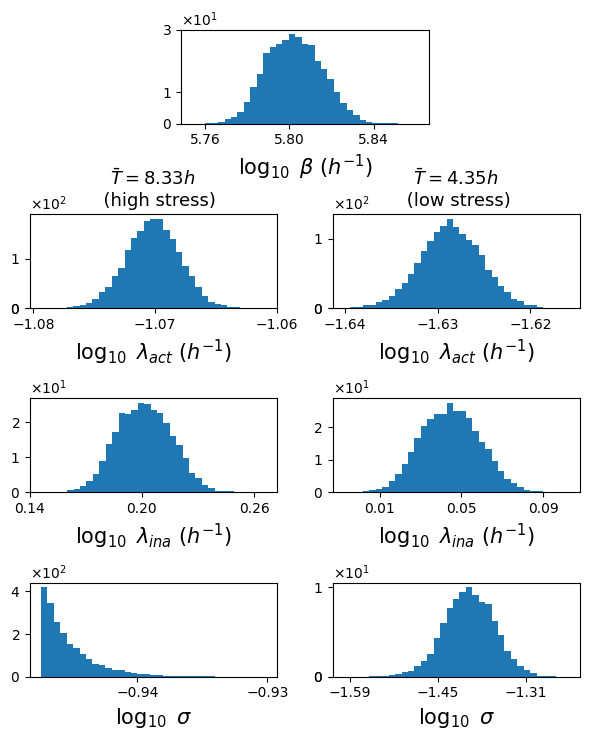

In [11]:
make_fig(g3[-100000:,:-1],g3[-100000:,-1],transform='log10')
plt.savefig('result.png',dpi=500)

In [12]:

models=[]
for dil in dils_str[:-1]:
    model = architecture.make_model(device)
    model_file = 'dilution{}/network.pt'.format(dil)
    model.load_state_dict(torch.load(model_file))
    
    for param in model.parameters():
        param.requires_grad = False
    models.append(model)
    

In [13]:
target = FCYeast2_simulator.FCYeast_simulator.target()

def grid_plot(x,param,model,log10 = False):
    xp = torch.linspace(x.min(),x.max(),101).to(device)
    lp = model.log_prob(xp.reshape(-1,1),torch.ones((101,4),device=device)*param)
    p = torch.exp(lp-lp.max())
    p *= 1/(p.sum()*(xp[1]-xp[0]))
    if log10:
        return xp.cpu()/l10,p.cpu()*l10
    return xp.cpu(),p.cpu()

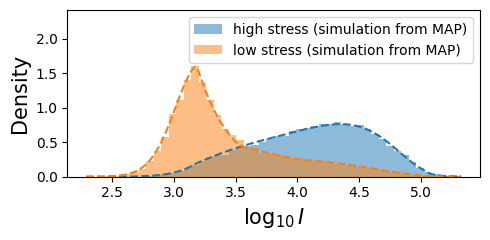

In [14]:
plt.figure(figsize=(5, 2.5)) 
colors = ['tab:blue','tab:orange']
labels = ['high stress (simulation from MAP)', 'low stress (simulation from MAP)']

params = FCYeast2_simulator.transform_to_arbitrary((best_param))
[plt.plot(*grid_plot(h[1]*l10,parami,model,log10=True),linestyle = 'dashed', color = color) for (parami,model,color) in zip(params,models,colors)]
[plt.hist(target.sample(params[i,:1],params[i,1:3],params[i,3:4],N=2**15,return_lparams=False).cpu().numpy()/l10, density=True, color = colors[i], bins=h[1],alpha=.5,label=labels[i])for i in range(2)]

plt.ylim(ylim)
plt.xlabel(r'$\log_{10} I$',fontsize=15)
plt.ylabel('Density',fontsize=15)
plt.legend()
plt.tight_layout()
plt.savefig('map_sim.png',dpi=500)

In [15]:
g1 = np.loadtxt('FCYeast2_MCMC/mcmc_real_results_29056datapoints.csv')
g2 = np.loadtxt('FCYeast2_MCMC/mcmc_real_results_58112datapoints.csv')
#g3 = np.loadtxt('FCYeast2_MCMC/mcmc_real_results_116224datapoints.csv')

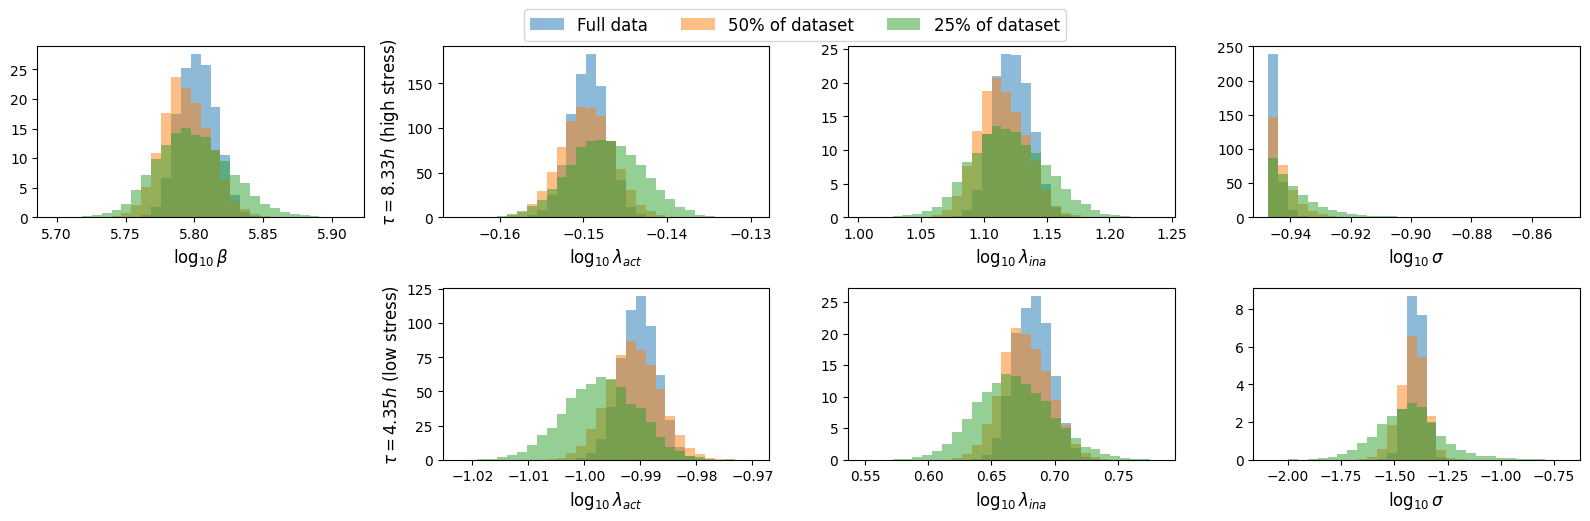

In [16]:
fig,ax = plt.subplots(2,4,figsize=(16,5))
lab = [r'$\beta$',r'$\lambda_{act}$',r'$\lambda_{ina}$',r'$\sigma$',r'$\lambda_{act}$',r'$\lambda_{ina}$',r'$\sigma$']
for axi,label,g25,g50,g100 in zip(ax.reshape(-1)[[0,1,2,3,5,6,7]],lab,
                       [g1[-100000:,i]/np.log(10) for i in range(7)],
                       [g2[-100000:,i]/np.log(10) for i in range(7)],
                       [g3[-100000:,i]/np.log(10) for i in range(7)]):
    h = np.linspace(g25.min(),g25.max(),31)
    axi.hist(g100,density=True,alpha=.5,bins=h,label='Full data')
    axi.hist(g50,density=True,alpha=.5,bins=h,label=r'50% of dataset')
    axi.hist(g25,density=True,alpha=.5,bins=h,label=r'25% of dataset')
    axi.set_xlabel(r'$\log_{10}$'+ label ,fontsize=12)
handles, labels = ax[0,0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=3, fontsize=12, bbox_to_anchor=(0.5, 1.05))

ax[0,1].set_ylabel(r'$\tau ={:.2f} h$ (high stress)'.format((1/dils[0])),fontsize=12)
ax[1,1].set_ylabel(r'$\tau ={:.2f} h$ (low stress)'.format((1/dils[1])),fontsize=12)


ax[1,0].set_facecolor("White")
ax[1,0].set_xticks([])
ax[1,0].set_yticks([])
for spine in ax[1,0].spines.values():
    spine.set_visible(False)

fig.tight_layout()
fig.savefig('SI_size.png',dpi=600,bbox_inches='tight')